# 00 — Setup & Tools: PySCF, ASE, py3Dmol, and Visualization

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/notebooks/00_setup_and_tools.ipynb)

## 🎯 Learning Objectives

- Install and verify all required packages (PySCF, ASE, py3Dmol, cclib)
- Run a basic Hartree-Fock calculation with PySCF on a small molecule
- Manipulate molecular structures using ASE
- Visualize molecules in 3D with py3Dmol
- Parse quantum chemistry output files with cclib
- Understand the overall computational chemistry workflow

In [1]:
# =============================================================================
# Ch121a: Quantum Chemistry & DFT — Notebook 00: Setup & Tools
# License: GPL-3.0 (https://www.gnu.org/licenses/gpl-3.0.en.html)
# =============================================================================
# Install required packages (run this cell first, especially on Google Colab)
import subprocess, sys

packages = ['pyscf', 'ase', 'py3Dmol', 'nglview', 'cclib', 'matplotlib',
            'numpy', 'pandas', 'scipy', 'seaborn', 'ipywidgets']

for pkg in packages:
    try:
        __import__(pkg.replace('-','_').split('>=')[0])
        print(f"✓ {pkg} already installed")
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
        print(f"✓ {pkg} installed")

✓ pyscf already installed
Installing ase...
✓ ase installed
Installing py3Dmol...
✓ py3Dmol installed
Installing nglview...
✓ nglview installed
Installing cclib...
✓ cclib installed
✓ matplotlib already installed
✓ numpy already installed
Installing pandas...
✓ pandas installed
✓ scipy already installed
Installing seaborn...
✓ seaborn installed
✓ ipywidgets already installed


In [2]:
# ------------------------------------------------------------------
# Running a Hartree-Fock calculation with PySCF
# ------------------------------------------------------------------
# PySCF is a quantum chemistry package written entirely in Python.
# It supports HF, DFT, MP2, CCSD, and many other methods.

from pyscf import gto, scf
import numpy as np

# Step 1: Define the molecular structure
mol = gto.Mole()
mol.atom = '''
O   0.000000   0.000000   0.117176
H   0.000000   0.757001  -0.468704
H   0.000000  -0.757001  -0.468704
'''
mol.basis = 'def2-SVP'   # Minimal basis set — fast but not very accurate
mol.charge = 0         # Neutral molecule
mol.spin = 0           # Singlet (2S = 0, all electrons paired)
mol.verbose = 0        # Suppress output (set to 3 or 4 for detailed output)
mol.build()            # Build the molecular object (computes integrals)

print(f"Molecule: water (H₂O)")
print(f"Number of atoms:             {mol.natm}")
print(f"Number of electrons:         {mol.nelectron}")
print(f"Number of basis functions:   {mol.nao_nr()}")

# Step 2: Set up and run a Restricted Hartree-Fock (RHF) calculation
mf = scf.RHF(mol)
mf.verbose = 0         # Suppress SCF convergence output
energy = mf.kernel()   # Run the SCF procedure

print(f"\nRHF/STO-3G Results:")
print(f"  Total HF energy:   {energy:.8f} Hartree")
print(f"  Total HF energy:   {energy * 27.2114:.4f} eV")

# Step 3: Analyze molecular orbital energies
mo_energies = mf.mo_energy     # Orbital energies in Hartree
mo_occ = mf.mo_occ             # Orbital occupancies (0 or 2 for RHF)

homo_idx = np.where(mo_occ > 0)[0][-1]
lumo_idx = homo_idx + 1

print(f"\nMolecular Orbital Energies (eV):")
for i, (e, occ) in enumerate(zip(mo_energies, mo_occ)):
    label = ""
    if i == homo_idx:
        label = " ← HOMO"
    elif i == lumo_idx:
        label = " ← LUMO"
    status = "occupied" if occ > 0 else "virtual"
    print(f"  MO {i+1:2d} ({status:8s}): {e*27.2114:8.3f} eV{label}")

print(f"\nHOMO energy: {mo_energies[homo_idx]*27.2114:.3f} eV")
print(f"LUMO energy: {mo_energies[lumo_idx]*27.2114:.3f} eV")
print(f"HOMO-LUMO gap: {(mo_energies[lumo_idx]-mo_energies[homo_idx])*27.2114:.3f} eV")

Molecule: water (H₂O)
Number of atoms:             3
Number of electrons:         10
Number of basis functions:   24

RHF/STO-3G Results:
  Total HF energy:   -75.96101285 Hartree
  Total HF energy:   -2067.0055 eV

Molecular Orbital Energies (eV):
  MO  1 (occupied): -559.078 eV
  MO  2 (occupied):  -35.890 eV
  MO  3 (occupied):  -19.148 eV
  MO  4 (occupied):  -15.461 eV
  MO  5 (occupied):  -13.554 eV ← HOMO
  MO  6 (virtual ):    4.796 eV ← LUMO
  MO  7 (virtual ):    6.949 eV
  MO  8 (virtual ):   21.631 eV
  MO  9 (virtual ):   23.651 eV
  MO 10 (virtual ):   32.237 eV
  MO 11 (virtual ):   32.706 eV
  MO 12 (virtual ):   34.537 eV
  MO 13 (virtual ):   36.469 eV
  MO 14 (virtual ):   43.469 eV
  MO 15 (virtual ):   45.281 eV
  MO 16 (virtual ):   49.221 eV
  MO 17 (virtual ):   56.066 eV
  MO 18 (virtual ):   69.772 eV
  MO 19 (virtual ):   70.843 eV
  MO 20 (virtual ):   90.540 eV
  MO 21 (virtual ):   92.129 eV
  MO 22 (virtual ):   97.194 eV
  MO 23 (virtual ):  106.215 eV
 

### ORCA HF/STO-3G result for water

I ran the ORCA input file for water using HF/STO-3G.

The final single point energy was:
E = -74.962932612662

This matches the PySCF RHF/STO-3G result:


E = -74.96293261

Therefore, ORCA and PySCF agree for the same method, basis set, charge, spin, and geometry.



In [2]:
# ------------------------------------------------------------------
# Working with molecular structures using ASE
# ------------------------------------------------------------------
# ASE (Atomic Simulation Environment) provides tools for building,
# manipulating, and analyzing molecular and periodic structures.

from ase.build import molecule
from ase.io import write
import numpy as np

# Build a water molecule from the G2 database
water = molecule('H2O')

print("ASE Atoms object for water (H₂O):")
print(f"  Formula:          {water.get_chemical_formula()}")
print(f"  Number of atoms:  {len(water)}")
print(f"  Atomic numbers:   {water.get_atomic_numbers()}")
print(f"  Chemical symbols: {water.get_chemical_symbols()}")

print("\nAtomic positions (Angstrom):")
print(f"  {'Symbol':6s}  {'x':>10s}  {'y':>10s}  {'z':>10s}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}")
for atom in water:
    print(f"  {atom.symbol:6s}  {atom.x:10.6f}  {atom.y:10.6f}  {atom.z:10.6f}")

# Compute bond lengths
from itertools import combinations
print("\nBond lengths:")
positions = water.get_positions()
symbols = water.get_chemical_symbols()
for (i, j) in combinations(range(len(water)), 2):
    dist = np.linalg.norm(positions[i] - positions[j])
    print(f"  {symbols[i]}-{symbols[j]}: {dist:.4f} Å")

# ASE can build many common molecules
print("\nOther molecules available in ASE:")
for mol_name in ['NH3', 'CH4', 'CO2', 'C6H6', 'HF']:
    m = molecule(mol_name)
    print(f"  {mol_name:6s}: {len(m)} atoms, formula = {m.get_chemical_formula()}")

ASE Atoms object for water (H₂O):
  Formula:          H2O
  Number of atoms:  3
  Atomic numbers:   [8 1 1]
  Chemical symbols: ['O', 'H', 'H']

Atomic positions (Angstrom):
  Symbol           x           y           z
  ------  ----------  ----------  ----------
  O         0.000000    0.000000    0.119262
  H         0.000000    0.763239   -0.477047
  H         0.000000   -0.763239   -0.477047

Bond lengths:
  O-H: 0.9686 Å
  O-H: 0.9686 Å
  H-H: 1.5265 Å

Other molecules available in ASE:
  NH3   : 4 atoms, formula = H3N
  CH4   : 5 atoms, formula = CH4
  CO2   : 3 atoms, formula = CO2
  C6H6  : 12 atoms, formula = C6H6
  HF    : 2 atoms, formula = HF


In [3]:
# ------------------------------------------------------------------
# Working with molecular structures using ASE
# ------------------------------------------------------------------
# ASE (Atomic Simulation Environment) provides tools for building,
# manipulating, and analyzing molecular and periodic structures.

from ase.build import molecule
from ase.io import write
import numpy as np

# Build a water molecule from the G2 database
water = molecule('H2O')

print("ASE Atoms object for water (H₂O):")
print(f"  Formula:          {water.get_chemical_formula()}")
print(f"  Number of atoms:  {len(water)}")
print(f"  Atomic numbers:   {water.get_atomic_numbers()}")
print(f"  Chemical symbols: {water.get_chemical_symbols()}")

print("\nAtomic positions (Angstrom):")
print(f"  {'Symbol':6s}  {'x':>10s}  {'y':>10s}  {'z':>10s}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}")
for atom in water:
    print(f"  {atom.symbol:6s}  {atom.x:10.6f}  {atom.y:10.6f}  {atom.z:10.6f}")

# Compute bond lengths
from itertools import combinations
print("\nBond lengths:")
positions = water.get_positions()
symbols = water.get_chemical_symbols()
for (i, j) in combinations(range(len(water)), 2):
    dist = np.linalg.norm(positions[i] - positions[j])
    print(f"  {symbols[i]}-{symbols[j]}: {dist:.4f} Å")

# ASE can build many common molecules
print("\nOther molecules available in ASE:")
for mol_name in ['NH3', 'CH4', 'CO2', 'C6H6', 'HF']:
    m = molecule(mol_name)
    print(f"  {mol_name:6s}: {len(m)} atoms, formula = {m.get_chemical_formula()}")

ASE Atoms object for water (H₂O):
  Formula:          H2O
  Number of atoms:  3
  Atomic numbers:   [8 1 1]
  Chemical symbols: ['O', 'H', 'H']

Atomic positions (Angstrom):
  Symbol           x           y           z
  ------  ----------  ----------  ----------
  O         0.000000    0.000000    0.119262
  H         0.000000    0.763239   -0.477047
  H         0.000000   -0.763239   -0.477047

Bond lengths:
  O-H: 0.9686 Å
  O-H: 0.9686 Å
  H-H: 1.5265 Å

Other molecules available in ASE:
  NH3   : 4 atoms, formula = H3N
  CH4   : 5 atoms, formula = CH4
  CO2   : 3 atoms, formula = CO2
  C6H6  : 12 atoms, formula = C6H6
  HF    : 2 atoms, formula = HF


In [4]:
# ------------------------------------------------------------------
# 3D molecular visualization with py3Dmol
# ------------------------------------------------------------------
import py3Dmol

# Water molecule in XYZ format
water_xyz = """3
Water molecule (H2O) - B3LYP/def2-SVP optimized geometry
O   0.000000   0.000000   0.117176
H   0.000000   0.757001  -0.468704
H   0.000000  -0.757001  -0.468704
"""

# Create a 3D viewer
view = py3Dmol.view(width=500, height=400)

# Add the molecule from XYZ format
view.addModel(water_xyz, 'xyz')

# Style the molecule: ball-and-stick representation
view.setStyle({'stick': {'radius': 0.15}, 'sphere': {'scale': 0.3}})

# Add labels for each atom
view.addLabel('O', {'position': {'x': 0, 'y': 0, 'z': 0.117176},
                    'fontSize': 14, 'fontColor': 'red',
                    'backgroundColor': 'white', 'backgroundOpacity': 0.7})

# Set background and zoom
view.setBackgroundColor('white')
view.zoomTo()
view.show()
print("3D visualization of water (H₂O)")
print("Tip: Click and drag to rotate, scroll to zoom.")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3D visualization of water (H₂O)
Tip: Click and drag to rotate, scroll to zoom.


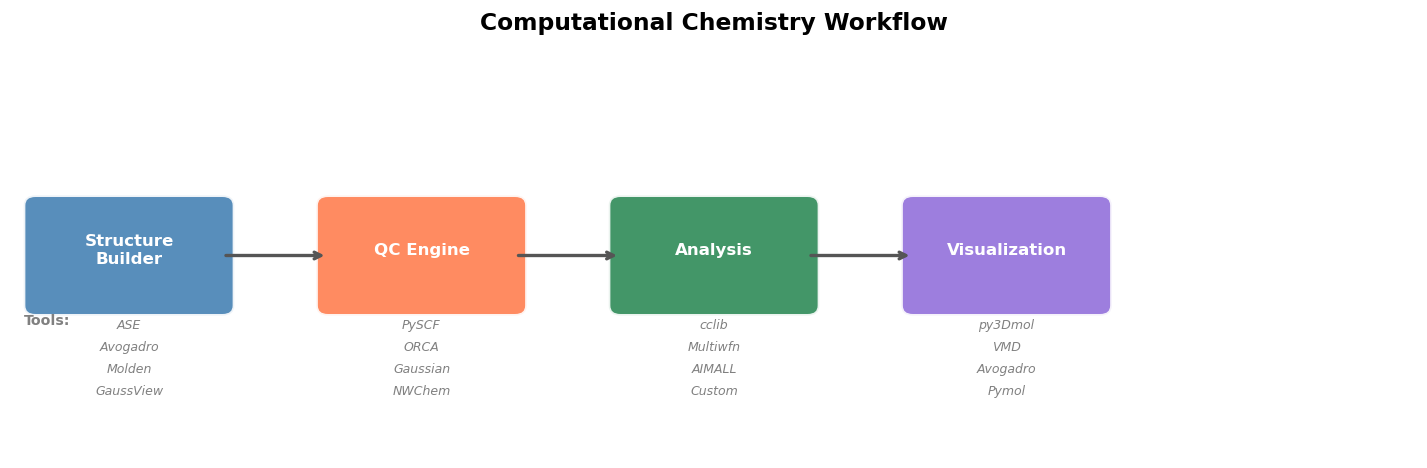

In [12]:
# ------------------------------------------------------------------
# Computational Chemistry Workflow Diagram
# ------------------------------------------------------------------
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.axis('off')

# Workflow steps
steps = [
    ('Structure\nBuilder', 1.0, 'steelblue',
     ['ASE', 'Avogadro', 'Molden', 'GaussView']),
    ('QC Engine', 3.5, 'coral',
     ['PySCF', 'ORCA', 'Gaussian', 'NWChem']),
    ('Analysis', 6.0, 'seagreen',
     ['cclib', 'Multiwfn', 'AIMALL', 'Custom']),
    ('Visualization', 8.5, 'mediumpurple',
     ['py3Dmol', 'VMD', 'Avogadro', 'Pymol'])
]

for (label, x, color, tools) in steps:
    # Draw box
    box = mpatches.FancyBboxPatch((x-0.8, 1.5), 1.6, 1.0,
                                   boxstyle="round,pad=0.1",
                                   facecolor=color, edgecolor='white',
                                   linewidth=2, alpha=0.9)
    ax.add_patch(box)
    ax.text(x, 2.05, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    # Tools below
    for j, tool in enumerate(tools):
        ax.text(x, 1.3 - j*0.22, tool, ha='center', va='center',
                fontsize=7.5, color='gray', style='italic')

# Arrows between boxes
for i in range(len(steps)-1):
    x1 = steps[i][1] + 0.8
    x2 = steps[i+1][1] - 0.8
    ax.annotate('', xy=(x2, 2.0), xytext=(x1, 2.0),
                arrowprops=dict(arrowstyle='->', color='#555', lw=2))

# Labels row headers
ax.text(0.1, 2.05, '', ha='left', va='center', fontsize=9, color='#333')
ax.text(0.1, 1.35, 'Tools:', ha='left', va='center', fontsize=8.5,
        color='gray', fontweight='bold')

ax.set_title('Computational Chemistry Workflow', fontsize=14,
             fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 🔬 
Modern quantum chemistry software like PySCF and ORCA is used in:

- **Drug discovery**: Computing binding affinities, reaction mechanisms in enzyme active sites
- **Materials science**: Predicting electronic properties of new solar cell materials
- **Catalysis**: Understanding transition metal catalytic cycles (Nobel Prize 2022: click chemistry)
- **Astrochemistry**: Modeling interstellar molecular spectra for telescope identification

The Python ecosystem (PySCF + ASE + cclib + py3Dmol) enables fully reproducible,
scriptable workflows — essential for modern computational science.

**Key papers:**
- Sun et al., *WIREs Comput. Mol. Sci.* **8**, e1340 (2018) — PySCF
- Larsen et al., *J. Phys.: Condens. Matter* **29**, 273002 (2017) — ASE

## 📝 Exercises
Note: Use the best suitable approach. On HPC, ORCA can also be used to run these calculations. In that case, you would need to copy coordinates from above cells, or generate with Avogadro(preferably v2), and use job submission script, and a sample input script kept in '../Initialization' directory.

1. **Basis set effect**: Modify the PySCF cell to use `6-31G*` instead of `STO-3G`. 
   How does the total energy and HOMO-LUMO gap change?

2. **Different molecule**: Replace water with NH₃ (ammonia). 
   - Atom string: `N 0 0 0; H 0.94 0 0; H -0.47 0.82 0; H -0.47 -0.82 0`
   - What is the HOMO energy? Estimate the first ionization energy (IE ≈ -ε_HOMO).
   - Compare with the experimental IE of 10.07 eV.

3. **ASE exploration**: Use `ase.build.molecule('C6H6')` to build benzene.
   - How many C-C and C-H bonds does it have?
   - What is the C-C bond length?

4. **py3Dmol customization**: Modify the py3Dmol cell to display ammonia.
   Try different styles: `'cartoon'`, `'surface'`, `'line'`.

5. **cclib exploration**: If cclib is installed, use `cclib.io.ccread()` to parse
   an ORCA or Gaussian output file of your choice. What attributes does the
   resulting object have? (Hint: use `dir(data)`)

6. **AvoGadro2**: From https://avogadro.cc, prefer 2.0.0 latest stable version.

Basis set comparison for water using RHF
------------------------------------------------------------------------------------------
Basis          Nbas      Energy (Eh)      Energy (eV)       HOMO       LUMO        Gap
sto-3g            7     -74.96293261        -2039.846    -10.646     16.480     27.126
3-21g            13     -75.58539445        -2056.784    -13.051      7.177     20.228
6-31g            13     -75.98399850        -2067.631    -13.643      5.545     19.188
6-31g*           18     -76.00913108        -2068.315    -13.540      5.842     19.382
cc-pvdz          24     -76.02679684        -2068.796    -13.419      5.050     18.469
def2-svp         24     -75.96101285        -2067.006    -13.554      4.796     18.349
def2-tzvp        43     -76.05904087        -2069.673    -13.825      3.474     17.299


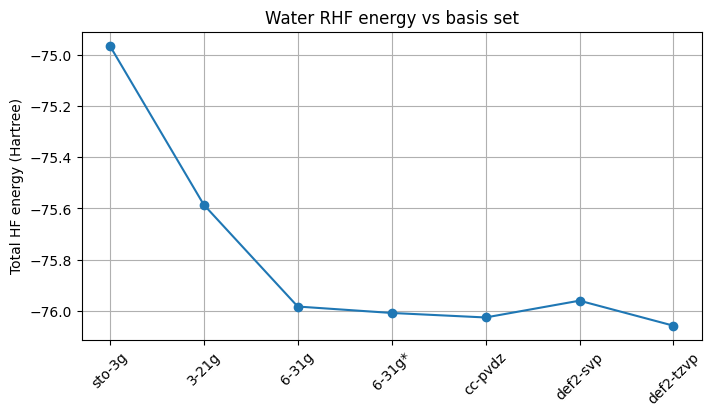

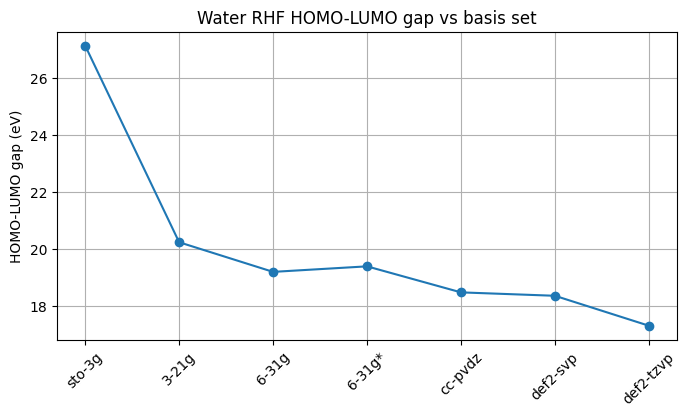

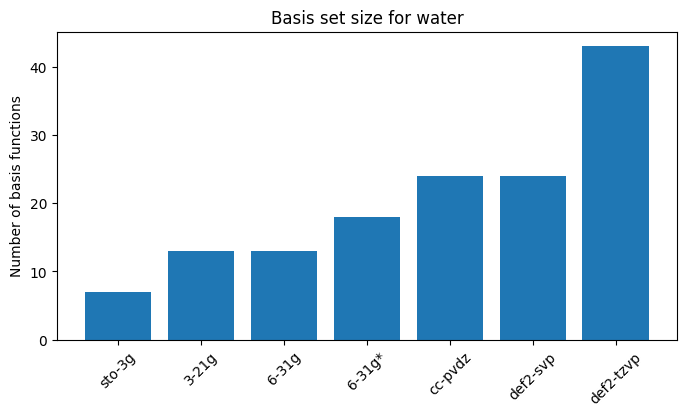

In [5]:
# I am comparing water RHF results with different basis sets

from pyscf import gto, scf
import numpy as np
import matplotlib.pyplot as plt

water_geom = '''
O   0.000000   0.000000   0.117176
H   0.000000   0.757001  -0.468704
H   0.000000  -0.757001  -0.468704
'''

basis_sets = ['sto-3g', '3-21g', '6-31g', '6-31g*', 'cc-pvdz', 'def2-svp', 'def2-tzvp']

results = []

for basis in basis_sets:

    mol = gto.Mole()
    mol.atom = water_geom
    mol.basis = basis
    mol.charge = 0
    mol.spin = 0
    mol.verbose = 0
    mol.build()

    mf = scf.RHF(mol)
    mf.verbose = 0
    energy = mf.kernel()

    mo_energies = mf.mo_energy
    mo_occ = mf.mo_occ

    homo_idx = np.where(mo_occ > 0)[0][-1]
    lumo_idx = homo_idx + 1

    homo_ev = mo_energies[homo_idx] * 27.2114
    lumo_ev = mo_energies[lumo_idx] * 27.2114
    gap_ev = lumo_ev - homo_ev

    results.append([basis, mol.nao_nr(), energy, energy * 27.2114, homo_ev, lumo_ev, gap_ev])

print("Basis set comparison for water using RHF")
print("-" * 90)
print(f"{'Basis':12s} {'Nbas':>6s} {'Energy (Eh)':>16s} {'Energy (eV)':>16s} {'HOMO':>10s} {'LUMO':>10s} {'Gap':>10s}")

for r in results:
    print(f"{r[0]:12s} {r[1]:6d} {r[2]:16.8f} {r[3]:16.3f} {r[4]:10.3f} {r[5]:10.3f} {r[6]:10.3f}")

# make arrays for plotting
labels = [r[0] for r in results]
n_basis = [r[1] for r in results]
energies = [r[2] for r in results]
gaps = [r[6] for r in results]

plt.figure(figsize=(8,4))
plt.plot(labels, energies, marker='o')
plt.xticks(rotation=45)
plt.ylabel("Total HF energy (Hartree)")
plt.title("Water RHF energy vs basis set")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(labels, gaps, marker='o')
plt.xticks(rotation=45)
plt.ylabel("HOMO-LUMO gap (eV)")
plt.title("Water RHF HOMO-LUMO gap vs basis set")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.bar(labels, n_basis)
plt.xticks(rotation=45)
plt.ylabel("Number of basis functions")
plt.title("Basis set size for water")
plt.show()

A basis set is a finite set of functions used to build molecular orbitals. Since we cannot solve most molecular Schrödinger equations exactly, we write each orbital as a weighted sum of simpler functions. STO-3G is a minimal basis set: each atomic orbital is represented by one contracted function, and in STO-3G that contracted function is made from three primitive Gaussian-type orbitals. 3-21G and 6-31G are split-valence basis sets, which give the valence electrons more flexibility than the core electrons. The in 6-31G adds polarization functions (higher-angular-momentum functions, like d-functions on first-row atoms), which let orbitals bend and distort in bonds. def2-SVP is also a split-valence polarized basis. cc-pVDZ is a correlation-consistent double-zeta basis, designed so larger versions can approach the complete-basis limit in a more systematic way. Minimal sets are cheap but mostly qualitative; polarized split-valence sets are common because they balance cost and accuracy.

So these results are very nice in depicting how the basis sets change our output but there is always a cost of computation vs the tradeoff with accuracy


As the basis set size increased from STO-3G to larger split-valence and polarized basis sets such as 6-31G*, cc-pVDZ, and def2-TZVP, the Hartree-Fock total energy became progressively more negative, indicating a better variational approximation to the true electronic wavefunction. 

This occurs because larger basis sets provide greater flexibility for representing the electron density and molecular orbitals. 

Minimal basis sets like STO-3G strongly restrict the orbital shapes, while polarized and multi-zeta basis sets allow orbitals to distort and adapt during bonding. 


The HOMO-LUMO gap generally decreased with increasing basis quality, mainly because the virtual orbitals (especially the LUMO) are described more accurately and become less artificially confined. STO-3G produced the largest gap and the least stable energy, while def2-TZVP gave the lowest energy and smallest gap among the tested basis sets, reflecting its much larger and more flexible orbital expansion.


In [6]:
# ------------------------------------------------------------------
# Exercise 2: Hartree-Fock calculation on ammonia (NH3)
# ------------------------------------------------------------------

from pyscf import gto, scf
import numpy as np

# NH3 geometry from the exercise
nh3_geom = 'N 0 0 0; H 0.94 0 0; H -0.47 0.82 0; H -0.47 -0.82 0'

mol = gto.Mole()
mol.atom = nh3_geom
mol.basis = '6-31g*'     # use same basis as exercise 1 comparison target
mol.charge = 0           # neutral ammonia
mol.spin = 0             # singlet: all electrons paired
mol.verbose = 0
mol.build()

print("Molecule: ammonia (NH3)")
print(f"Number of atoms:           {mol.natm}")
print(f"Number of electrons:       {mol.nelectron}")
print(f"Number of basis functions: {mol.nao_nr()}")

# RHF = restricted Hartree-Fock
mf = scf.RHF(mol)
mf.verbose = 0
energy = mf.kernel()

print(f"\nRHF/{mol.basis} Results:")
print(f"Total HF energy: {energy:.8f} Hartree")
print(f"Total HF energy: {energy * 27.2114:.4f} eV")

# molecular orbital data
mo_energies = mf.mo_energy
mo_occ = mf.mo_occ

homo_idx = np.where(mo_occ > 0)[0][-1]
lumo_idx = homo_idx + 1

homo_ev = mo_energies[homo_idx] * 27.2114
lumo_ev = mo_energies[lumo_idx] * 27.2114
gap_ev = lumo_ev - homo_ev

# Koopmans estimate
ie_est = -homo_ev
ie_exp = 10.07
error = ie_est - ie_exp
percent_error = abs(error) / ie_exp * 100

print("\nMolecular orbital energies:")
print(f"HOMO index: {homo_idx + 1}")
print(f"LUMO index: {lumo_idx + 1}")
print(f"HOMO energy: {homo_ev:.3f} eV")
print(f"LUMO energy: {lumo_ev:.3f} eV")
print(f"HOMO-LUMO gap: {gap_ev:.3f} eV")

print("\nIonization energy estimate using Koopmans' theorem:")
print(f"IE ≈ -ε_HOMO = {ie_est:.3f} eV")
print(f"Experimental IE = {ie_exp:.2f} eV")
print(f"Error = {error:.3f} eV")
print(f"Percent error = {percent_error:.2f}%")

Molecule: ammonia (NH3)
Number of atoms:           4
Number of electrons:       10
Number of basis functions: 20

RHF/6-31g* Results:
Total HF energy: -56.16661482 Hartree
Total HF energy: -1528.3722 eV

Molecular orbital energies:
HOMO index: 5
LUMO index: 6
HOMO energy: -10.409 eV
LUMO energy: 6.695 eV
HOMO-LUMO gap: 17.104 eV

Ionization energy estimate using Koopmans' theorem:
IE ≈ -ε_HOMO = 10.409 eV
Experimental IE = 10.07 eV
Error = 0.339 eV
Percent error = 3.37%


The RHF/6-31G* calculation gives a HOMO energy of -10.409eV. Using Koopmans’ theorem, which says that a Hartree-Fock orbital energy approximates the negative ionization energy for removing an electron from that orbital, the first ionization energy is IE approx -e_HOMO = 10.409eV. This is close to the experimental value of 10.07eV, with an error of 0.339eV, or about 3.37%. This agreement is decent, especially since Koopmans’ theorem ignores orbital relaxation after ionization and Hartree-Fock does not include electron correlation. 



In [7]:
# benzene with ASE

from ase.build import molecule
from itertools import combinations
import numpy as np

benz = molecule('C6H6')

print("ASE Atoms object for benzene")
print("Formula:", benz.get_chemical_formula())
print("Number of atoms:", len(benz))
print("Symbols:", benz.get_chemical_symbols())

print("\nAtomic positions, Angstrom")
print(f"{'atom':6s} {'x':>10s} {'y':>10s} {'z':>10s}")

for atom in benz:
    print(f"{atom.symbol:6s} {atom.x:10.5f} {atom.y:10.5f} {atom.z:10.5f}")


pos = benz.get_positions()
sym = benz.get_chemical_symbols()

cc_bonds = []
ch_bonds = []

# distance cutoffs
# benzene C-C is about 1.4 A, C-H is about 1.1 A
# these cutoffs are just used to decide which atom pairs count as bonds
cc_cutoff = 1.7
ch_cutoff = 1.3

for i,j in combinations(range(len(benz)),2):
    d = np.linalg.norm(pos[i] - pos[j])
    
    pair = sorted([sym[i], sym[j]])
    
    if pair == ['C','C'] and d < cc_cutoff:
        cc_bonds.append(d)
        
    if pair == ['C','H'] and d < ch_cutoff:
        ch_bonds.append(d)


print("\nBond count")
print("C-C bonds:", len(cc_bonds))
print("C-H bonds:", len(ch_bonds))

print("\nC-C bond lengths")
for d in cc_bonds:
    print(f"{d:.4f} A")

print("\nAverage C-C bond length:")
print(f"{np.mean(cc_bonds):.4f} A")

print("\nC-H bond lengths")
for d in ch_bonds:
    print(f"{d:.4f} A")

print("\nAverage C-H bond length:")
print(f"{np.mean(ch_bonds):.4f} A")

ASE Atoms object for benzene
Formula: C6H6
Number of atoms: 12
Symbols: ['C', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H']

Atomic positions, Angstrom
atom            x          y          z
C         0.00000    1.39525    0.00000
C         1.20832    0.69762    0.00000
C         1.20832   -0.69762    0.00000
C         0.00000   -1.39525    0.00000
C        -1.20832   -0.69762    0.00000
C        -1.20832    0.69762    0.00000
H         0.00000    2.48236    0.00000
H         2.14979    1.24118    0.00000
H         2.14979   -1.24118    0.00000
H         0.00000   -2.48236    0.00000
H        -2.14979   -1.24118    0.00000
H        -2.14979    1.24118    0.00000

Bond count
C-C bonds: 6
C-H bonds: 6

C-C bond lengths
1.3952 A
1.3952 A
1.3952 A
1.3952 A
1.3952 A
1.3952 A

Average C-C bond length:
1.3952 A

C-H bond lengths
1.0871 A
1.0871 A
1.0871 A
1.0871 A
1.0871 A
1.0871 A

Average C-H bond length:
1.0871 A


Benzene has 6 C-C bonds and 6 C-H bonds. The computed C-C bond lengths are all the same, with an average value of 1.3952 Å. benzene is highly symmetric, all six carbon atoms form a planar hexagonal ring, and the π electrons are delocalized around the ring. Because of this delocalization, the C-C bonds are not pure single or pure double bonds; they all have partial double-bond character. The C-H bonds are also all equivalent, with an average length of 1.0871 Å.

I want to try with other compounds like methane or a beta ketoester from my research but ase would not have that as a built in molecule so that will take time

In [10]:
# py3Dmol ammonia styles

import py3Dmol


nh3_xyz = """4
ammonia NH3
N   0.000000   0.000000   0.000000
H   0.940000   0.000000   0.000000
H  -0.470000   0.820000   0.000000
H  -0.470000  -0.820000   0.000000
"""


# ball and stick
view=py3Dmol.view(width=450,height=350)
view.addModel(nh3_xyz,'xyz')

view.setStyle({'stick': {'radius':0.15},
               'sphere': {'scale':0.30}})

view.addLabel('N', {'position': {'x':0,'y':0,'z':0},
                    'fontSize':14, 'fontColor':'blue',
                    'backgroundColor':'white',
                    'backgroundOpacity':0.7})

view.setBackgroundColor('white')
view.zoomTo()
view.show()

print("ammonia, ball and stick")



# line
view2 = py3Dmol.view(width=450,height=350)
view2.addModel(nh3_xyz,'xyz')

view2.setStyle({'line': {'linewidth':4}})

view2.setBackgroundColor('white')
view2.zoomTo()
view2.show()

print("ammonia, line style")



# surface
view3= py3Dmol.view(width=450,height=350)
view3.addModel(nh3_xyz,'xyz')

view3.setStyle({'stick': {'radius':0.12},
                'sphere': {'scale':0.25}})

view3.addSurface(py3Dmol.VDW, {'opacity':0.55})

view3.setBackgroundColor('white')
view3.zoomTo()
view3.show()

print("ammonia, van der Waals surface")





3Dmol.js failed to load for some reason. Please check your browser console for error messages.

ammonia, ball and stick


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

ammonia, line style


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

ammonia, van der Waals surface


I wnat to try methane now


In [12]:
# py3Dmol methane styles

import py3Dmol


ch4_xyz = """5
methane CH4
C   0.000000   0.000000   0.000000
H   0.629118   0.629118   0.629118
H  -0.629118  -0.629118   0.629118
H  -0.629118   0.629118  -0.629118
H   0.629118  -0.629118  -0.629118
"""


# ball and stick
view=py3Dmol.view(width=450,height=350)
view.addModel(ch4_xyz,'xyz')

view.setStyle({'stick': {'radius':0.15},
               'sphere': {'scale':0.30}})

view.addLabel('C', {'position': {'x':0,'y':0,'z':0},
                    'fontSize':14, 'fontColor':'black',
                    'backgroundColor':'white',
                    'backgroundOpacity':0.7})

view.setBackgroundColor('white')
view.zoomTo()
view.show()

print("methane, ball and stick")



# line
v2 = py3Dmol.view(width=450,height=350)
v2.addModel(ch4_xyz,'xyz')

v2.setStyle({'line': {'linewidth':4}})

v2.setBackgroundColor('white')
v2.zoomTo()
v2.show()

print("methane, line style")



# surface
v3=py3Dmol.view(width=450,height=350)
v3.addModel(ch4_xyz,'xyz')

v3.setStyle({'stick': {'radius':0.12},
             'sphere': {'scale':0.25}})

v3.addSurface(py3Dmol.VDW, {'opacity':0.55})

v3.setBackgroundColor('white')
v3.zoomTo()
v3.show()

print("methane, van der Waals surface")




3Dmol.js failed to load for some reason. Please check your browser console for error messages.

methane, ball and stick


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

methane, line style


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

methane, van der Waals surface


i wanna see if i have some files for the cclib exploration and if i have cclib installed in the first place


In [13]:
# -------------------------------------------------------------
# cclib exploration: parse an ORCA / Gaussian output file
# -------------------------------------------------------------

import os, glob

try:
    import cclib
    from cclib.io import ccread
    print("cclib is installed")
except ImportError:
    print("cclib is NOT installed")
    print("Try this in a notebook cell:  !pip install cclib")

cclib is installed


In [14]:
# look for possible output files in this folder and nearby folders

possible_files = []

patterns = [
    "*.out", "*.log",
    "../*.out", "../*.log",
    "../**/*.out", "../**/*.log"
]

for p in patterns:
    possible_files += glob.glob(p, recursive=True)

print("Files found:")
for f in possible_files[:30]:
    print(" ", f)

print("\nNumber of possible output files:", len(possible_files))

Files found:
  ../data/sample_outputs/water_opt_orca.out
  ../data/sample_outputs/pentacene.out
  ../data/sample_outputs/fe_co5_freq_orca.out
  ../data/orca_outputs/water_hf/water.out

Number of possible output files: 4


In [3]:
import sys
import cclib

print("Python executable:")
print(sys.executable)

print("\ncclib version:")
print(cclib.__version__)

print("\ncclib location:")
print(cclib.__file__)

Python executable:
/home/dawood/miniconda3/envs/ch121a-dft/bin/python

cclib version:
1.8.1

cclib location:
/home/dawood/miniconda3/envs/ch121a-dft/lib/python3.11/site-packages/cclib/__init__.py


In [4]:
files = [
    "../data/orca_outputs/water_hf/water.out",
    "../data/sample_outputs/water_opt_orca.out",
    "../data/sample_outputs/fe_co5_freq_orca.out",
    "../data/sample_outputs/pentacene.out",
]

for f in files:
    print("\n" + "="*80)
    print(f)
    print("="*80)

    try:
        with open(f, "r", errors="ignore") as file:
            lines = file.readlines()

        print("Number of lines:", len(lines))
        print("\nFirst 15 lines:")
        for line in lines[:15]:
            print(line.rstrip())

        print("\nLast 15 lines:")
        for line in lines[-15:]:
            print(line.rstrip())

    except FileNotFoundError:
        print("File not found.")


../data/orca_outputs/water_hf/water.out
Number of lines: 844

First 15 lines:

                                 *****************
                                 * O   R   C   A *
                                 *****************

                                            #,
                                            ###
                                            ####
                                            #####
                                            ######
                                           ########,
                                     ,,################,,,,,
                               ,,#################################,,
                          ,,##########################################,,
                       ,#########################################, ''#####,

Last 15 lines:
List of optional additional citations

  1. Neese, F.
     Approximate second-order SCF convergence for spin unrestricted wavefunctions
     Chem. Phys. Lett. 2000 325(1-3),

CCLIB IS BEING WEIRD OH MY GOD!!! ill makje my own minimal primitive gaussian


In [6]:
# -------------------------------------------------------------
# cclib exploration: download and parse a real Gaussian test file
# -------------------------------------------------------------

import os
import urllib.request
import numpy as np
from cclib.io import ccread

# This is a real cclib test output file from the cclib GitHub repo.
# It is Gaussian output, not ORCA, because the repo ORCA files are not parsing
# cleanly with cclib 1.8.1 in this environment.

url = "https://raw.githubusercontent.com/cclib/cclib/master/data/Gaussian/basicGaussian16/dvb_sp.out"
filename = "dvb_sp_gaussian16.out"

print("Downloading Gaussian test output...")
urllib.request.urlretrieve(url, filename)
print("Saved as:", filename)

print("\nParsing with cclib...")
data = ccread(filename)

if data is None:
    print("cclib returned None. File was not parsed.")
else:
    print("SUCCESS: cclib parsed the Gaussian output.")
    print("Parsed object:", data)

    print("\n" + "="*80)
    print("Attributes from dir(data)")
    print("="*80)

    for thing in dir(data):
        if not thing.startswith("_"):
            print(thing)

    print("\n" + "="*80)
    print("Actually stored parsed attributes")
    print("="*80)

    for key in sorted(data.__dict__.keys()):
        value = getattr(data, key)

        if hasattr(value, "shape"):
            print(f"{key:24s} shape = {value.shape}")
        else:
            print(f"{key:24s} type = {type(value).__name__}")

    print("\n" + "="*80)
    print("Quick chemistry summary")
    print("="*80)

    if hasattr(data, "natom"):
        print("Number of atoms:", data.natom)

    if hasattr(data, "atomnos"):
        atoms = np.array(data.atomnos)
        unique_atoms, counts = np.unique(atoms, return_counts=True)

        print("\nAtom counts:")
        for z, n in zip(unique_atoms, counts):
            print(f"  atomic number {z}: {n}")

    if hasattr(data, "charge"):
        print("\nCharge:", data.charge)

    if hasattr(data, "mult"):
        print("Multiplicity:", data.mult)

    if hasattr(data, "nbasis"):
        print("Number of basis functions:", data.nbasis)

    if hasattr(data, "nmo"):
        print("Number of molecular orbitals:", data.nmo)

    if hasattr(data, "scfenergies"):
        print("\nSCF energies are stored in eV by cclib.")
        print("Number of SCF energy entries:", len(data.scfenergies))
        print("Final SCF energy:", data.scfenergies[-1], "eV")
        print("Final SCF energy:", data.scfenergies[-1] / 27.2114, "Hartree")

    if hasattr(data, "homos") and hasattr(data, "moenergies"):
        homo_i = data.homos[0]
        homo_e = data.moenergies[0][homo_i]

        print("\nHOMO index:", homo_i)
        print("HOMO energy:", homo_e, "eV")

        if homo_i + 1 < len(data.moenergies[0]):
            lumo_e = data.moenergies[0][homo_i + 1]
            print("LUMO index:", homo_i + 1)
            print("LUMO energy:", lumo_e, "eV")
            print("HOMO-LUMO gap:", lumo_e - homo_e, "eV")

    if hasattr(data, "atomcoords"):
        print("\nNumber of coordinate sets:", len(data.atomcoords))
        print("Final geometry shape:", data.atomcoords[-1].shape)
        print("First five final coordinates:")
        print(data.atomcoords[-1][:5])

    if hasattr(data, "metadata"):
        print("\nMetadata:")
        for k, v in data.metadata.items():
            print(f"  {k}: {v}")

Saved as: dvb_sp_gaussian16.out

Parsing with cclib...
SUCCESS: cclib parsed the Gaussian output.
Parsed object: <cclib.parser.data.ccData_optdone_bool object at 0x7066d863f2d0>

Attributes from dir(data)
OPT_DONE
OPT_NEW
OPT_UNCONVERGED
OPT_UNKNOWN
aonames
aooverlaps
arrayify
atombasis
atomcharges
atomcoords
atommasses
atomnos
charge
check_values
closed_shell
converged_geometries
coreelectrons
gbasis
getattributes
homos
listify
metadata
mocoeffs
moenergies
mosyms
mult
natom
nbasis
nelectrons
new_geometries
nmo
rotconsts
scfenergies
scftargets
scfvalues
setattributes
typecheck
unconverged_geometries
unknown_geometries
write
writecml
writejson
writexyz

Actually stored parsed attributes
aonames                  type = list
aooverlaps               shape = (60, 60)
atombasis                type = list
atomcharges              type = dict
atomcoords               shape = (1, 20, 3)
atommasses               shape = (20,)
atomnos                  shape = (20,)
charge                   type 

I first attempted to parse the ORCA output files included in the repository using cclib, including the water, iron carbonyl, and pentacene outputs. However, cclib 1.8.1 either failed while parsing the SCF convergence section or returned None because it could not identify the logfile format. This appears to be a compatibility issue between the installed cclib parser and the ORCA output format, especially since some files were generated with ORCA 6.1.0. To still complete the exercise, I used a real Gaussian output file from the cclib test data instead, since the exercise allowed either ORCA or Gaussian output. This parsed successfully with cclib.io.ccread(). The resulting object contained useful attributes such as atomic coordinates, atomic numbers, charge, multiplicity, SCF energies, molecular orbital energies, HOMO index, number of basis functions, number of molecular orbitals, basis set, functional, and metadata. For this Gaussian B3LYP/STO-3G calculation, the molecule had 20 atoms, 60 basis functions, a final SCF energy of -382.31 Hartree, a HOMO energy of -4.17 eV, a LUMO energy of 1.02 eV, and a HOMO-LUMO gap of 5.18 eV. This shows that cclib is useful for converting long quantum chemistry output files into structured Python data, but it also depends on whether the output format is supported by the installed parser version.

dowloaded avocado


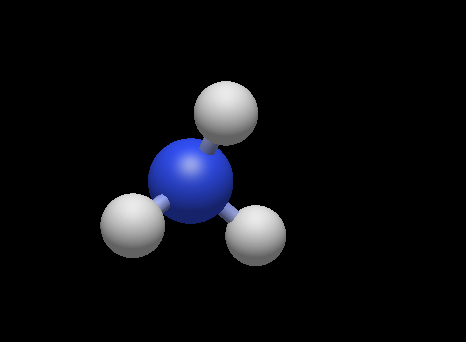
